# Sinusoidal Positional Encoding — From First Principles

This notebook walks through:
1. **Why** transformers need positional encoding
2. **How** the sinusoidal encoding creates a unique fingerprint per position
3. **Visualizing** the frequency spectrum and the "clock" analogy
4. **How** positional information flows into Q, K, V vectors and affects attention
5. **Why** this approach struggles to scale beyond training length

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme(style='whitegrid')
%matplotlib inline

## Part 1: The Problem — Attention is Permutation Invariant

Self-attention computes:

$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$

The claim: **attention treats its input as a bag (set) of tokens, not a sequence.**

What does this mean concretely? If the same words appear in a different order,
each word gets the **exact same output representation** — the model literally cannot
tell the two sentences apart.

Let's prove this with "dog bites man" vs "man bites dog":

In [2]:
torch.manual_seed(42)

d_model = 8

# Fixed embeddings for each word (same word = same vector, always)
emb_dog   = torch.randn(d_model)
emb_bites = torch.randn(d_model)
emb_man   = torch.randn(d_model)

# Two sentences with DIFFERENT word order but SAME words
sentence_1 = torch.stack([emb_dog, emb_bites, emb_man]).unsqueeze(0)   # "dog bites man"
sentence_2 = torch.stack([emb_man, emb_bites, emb_dog]).unsqueeze(0)   # "man bites dog"

W_q = torch.randn(d_model, d_model)
W_k = torch.randn(d_model, d_model)
W_v = torch.randn(d_model, d_model)

def attention(X, W_q, W_k, W_v):
    Q = X @ W_q
    K = X @ W_k
    V = X @ W_v
    scores = Q @ K.transpose(-2, -1) / (d_model ** 0.5)
    weights = torch.softmax(scores, dim=-1)
    return weights @ V, weights

out1, attn1 = attention(sentence_1, W_q, W_k, W_v)  # "dog bites man"
out2, attn2 = attention(sentence_2, W_q, W_k, W_v)  # "man bites dog"

print('=== Sentence 1: "dog bites man" ===')
print(f'  Output for "dog"   (pos 0): {out1[0, 0, :4].detach().numpy().round(4)}')
print(f'  Output for "bites" (pos 1): {out1[0, 1, :4].detach().numpy().round(4)}')
print(f'  Output for "man"   (pos 2): {out1[0, 2, :4].detach().numpy().round(4)}')
print()
print('=== Sentence 2: "man bites dog" ===')
print(f'  Output for "man"   (pos 0): {out2[0, 0, :4].detach().numpy().round(4)}')
print(f'  Output for "bites" (pos 1): {out2[0, 1, :4].detach().numpy().round(4)}')
print(f'  Output for "dog"   (pos 2): {out2[0, 2, :4].detach().numpy().round(4)}')
print()
print('=== Comparing the SAME WORD across both sentences ===')
print(f'  "dog" output in sent1 vs sent2:   diff = {(out1[0,0] - out2[0,2]).abs().max().item():.2e}')
print(f'  "bites" output in sent1 vs sent2: diff = {(out1[0,1] - out2[0,1]).abs().max().item():.2e}')
print(f'  "man" output in sent1 vs sent2:   diff = {(out1[0,2] - out2[0,0]).abs().max().item():.2e}')
print()
print('→ Every word gets the EXACT SAME output regardless of position.')
print('  "dog" in "dog bites man" = "dog" in "man bites dog".')
print('  The model has NO IDEA who is doing the biting!')

=== Sentence 1: "dog bites man" ===
  Output for "dog"   (pos 0): [-3.5611 -3.8533 -6.5566  0.5098]
  Output for "bites" (pos 1): [ 0.94   -4.5953 -0.4694 -4.17  ]
  Output for "man"   (pos 2): [ 1.4406  4.1211  1.81   -1.926 ]

=== Sentence 2: "man bites dog" ===
  Output for "man"   (pos 0): [ 1.4406  4.1211  1.81   -1.926 ]
  Output for "bites" (pos 1): [ 0.94   -4.5953 -0.4694 -4.17  ]
  Output for "dog"   (pos 2): [-3.5611 -3.8533 -6.5566  0.5098]

=== Comparing the SAME WORD across both sentences ===
  "dog" output in sent1 vs sent2:   diff = 0.00e+00
  "bites" output in sent1 vs sent2: diff = 4.77e-07
  "man" output in sent1 vs sent2:   diff = 1.19e-07

→ Every word gets the EXACT SAME output regardless of position.
  "dog" in "dog bites man" = "dog" in "man bites dog".
  The model has NO IDEA who is doing the biting!


### Why does this happen?

When we go from `[dog, bites, man]` to `[man, bites, dog]`, the attention matrix
rows and columns just get permuted — but each token's **relationship to every other
token** stays identical. "dog" attends to "bites" with the same weight in both sentences.

The attention weight between two tokens depends only on their **content** (the Q·K dot product),
not on **where** they sit in the sequence. So shuffling positions just shuffles the matrix — it
doesn't change any of the actual attention values.

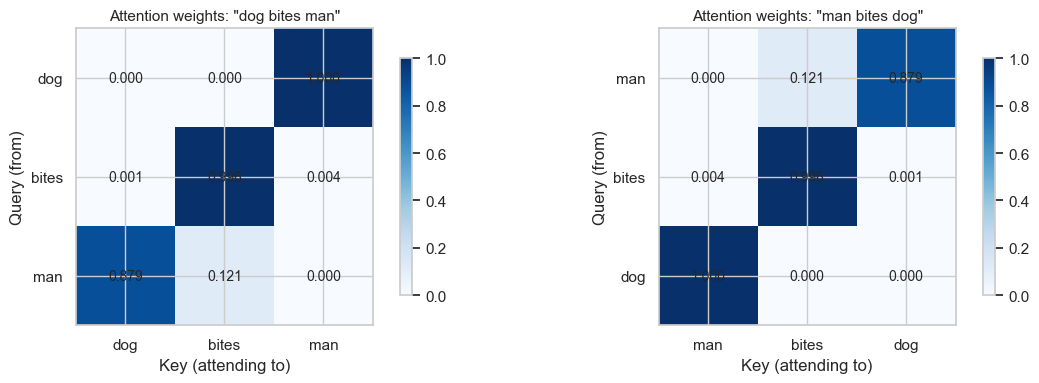

Compare: dog→bites in sent1 = 0.0000   dog→bites in sent2 = 0.0000
Compare: dog→man in sent1   = 1.0000   dog→man in sent2   = 1.0000

The attention weights between any pair of words are IDENTICAL.
The matrix is just permuted — the relationships are unchanged.

THIS is why we need positional encoding: without it, the transformer
treats language as a bag of words. Word ORDER is completely invisible.


In [12]:
labels1 = ['dog', 'bites', 'man']
labels2 = ['man', 'bites', 'dog']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, attn, labels, title in zip(axes, [attn1, attn2], [labels1, labels2],
                                     ['"dog bites man"', '"man bites dog"']):
    im = ax.imshow(attn[0].detach().numpy(), cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks(range(3))
    ax.set_yticks(range(3))
    ax.set_xticklabels(labels, fontsize=11)
    ax.set_yticklabels(labels, fontsize=11)
    ax.set_xlabel('Key (attending to)')
    ax.set_ylabel('Query (from)')
    ax.set_title(f'Attention weights: {title}', fontsize=11)
    # Annotate cells with values
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f'{attn[0,i,j].item():.3f}', ha='center', va='center', fontsize=10)
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.show()

print('Compare: dog→bites in sent1 =', f'{attn1[0,0,1].item():.4f}',
       '  dog→bites in sent2 =', f'{attn2[0,2,1].item():.4f}')
print('Compare: dog→man in sent1   =', f'{attn1[0,0,2].item():.4f}',
       '  dog→man in sent2   =', f'{attn2[0,2,0].item():.4f}')
print()
print('The attention weights between any pair of words are IDENTICAL.')
print('The matrix is just permuted — the relationships are unchanged.')
print()
print('THIS is why we need positional encoding: without it, the transformer')
print('treats language as a bag of words. Word ORDER is completely invisible.')

## Part 2: The Sinusoidal Positional Encoding Formula

From "Attention Is All You Need" (Vaswani et al., 2017):

$$PE(pos, 2i) = \sin\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$
$$PE(pos, 2i+1) = \cos\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

Where:
- `pos` = position in the sequence (0, 1, 2, ...)
- `i` = dimension index (0, 1, 2, ..., d_model/2 - 1)
- `d_model` = embedding dimension

Each pair of dimensions `(2i, 2i+1)` forms a **sin/cos pair** at a specific frequency.

### Intuition: Think of it like a clock
- Dimension pair 0: **seconds hand** (fast oscillation, high frequency)
- Dimension pair 1: **minutes hand** (slower)
- ...
- Last dimension pair: **year hand** (very slow oscillation, low frequency)

Just like a timestamp `14:32:07` uniquely identifies a time, the combination of all
these oscillations at different frequencies creates a **unique fingerprint** for each position.

In [3]:
def sinusoidal_positional_encoding(max_len, d_model):
    """
    Generate the sinusoidal positional encoding matrix.
    Returns: (max_len, d_model) tensor
    """
    pe = torch.zeros(max_len, d_model)
    position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)  # (max_len, 1)
    
    # Each dimension pair oscillates at a different frequency.
    # div_term = 1 / 10000^(2i / d_model)
    # We compute it in log-space for numerical stability:
    #   exp(2i * -log(10000) / d_model) = 1 / 10000^(2i/d_model)
    div_term = torch.exp(
        torch.arange(0, d_model, 2, dtype=torch.float) * (-np.log(10000.0) / d_model)
    )  # shape: (d_model/2,)
    
    pe[:, 0::2] = torch.sin(position * div_term)  # even dims: sin
    pe[:, 1::2] = torch.cos(position * div_term)  # odd dims: cos
    
    return pe

d_model = 64
max_len = 128
pe = sinusoidal_positional_encoding(max_len, d_model)

print(f'PE shape: {pe.shape}  →  ({max_len} positions, {d_model} dimensions)')
print(f'\nFirst 8 dims of PE[0]: {pe[0, :8].numpy().round(3)}')
print(f'First 8 dims of PE[1]: {pe[1, :8].numpy().round(3)}')
print(f'First 8 dims of PE[2]: {pe[2, :8].numpy().round(3)}')

PE shape: torch.Size([128, 64])  →  (128 positions, 64 dimensions)

First 8 dims of PE[0]: [0. 1. 0. 1. 0. 1. 0. 1.]
First 8 dims of PE[1]: [0.841 0.54  0.682 0.732 0.533 0.846 0.409 0.912]
First 8 dims of PE[2]: [ 0.909 -0.416  0.997  0.071  0.902  0.431  0.747  0.665]


## Part 3: Visualizing the Positional Fingerprints

### 3a. The full PE matrix as a heatmap

Each row is a position, each column is a dimension. Notice how:
- Left columns (low `i`) oscillate rapidly → high frequency ("seconds hand")
- Right columns (high `i`) change very slowly → low frequency ("year hand")

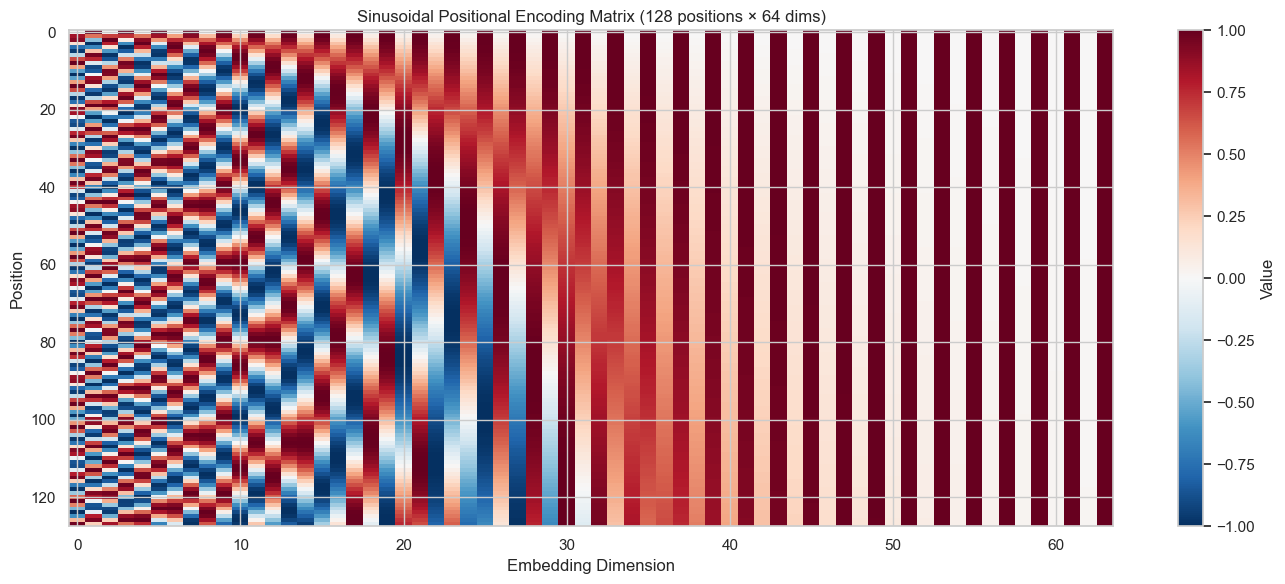

In [4]:
fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(pe.numpy(), aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xlabel('Embedding Dimension')
ax.set_ylabel('Position')
ax.set_title('Sinusoidal Positional Encoding Matrix (128 positions × 64 dims)')
plt.colorbar(im, ax=ax, label='Value')
plt.tight_layout()
plt.show()

### 3b. Individual dimension pairs — the "clock hands"

Let's plot a few sin/cos pairs to see the different frequencies:

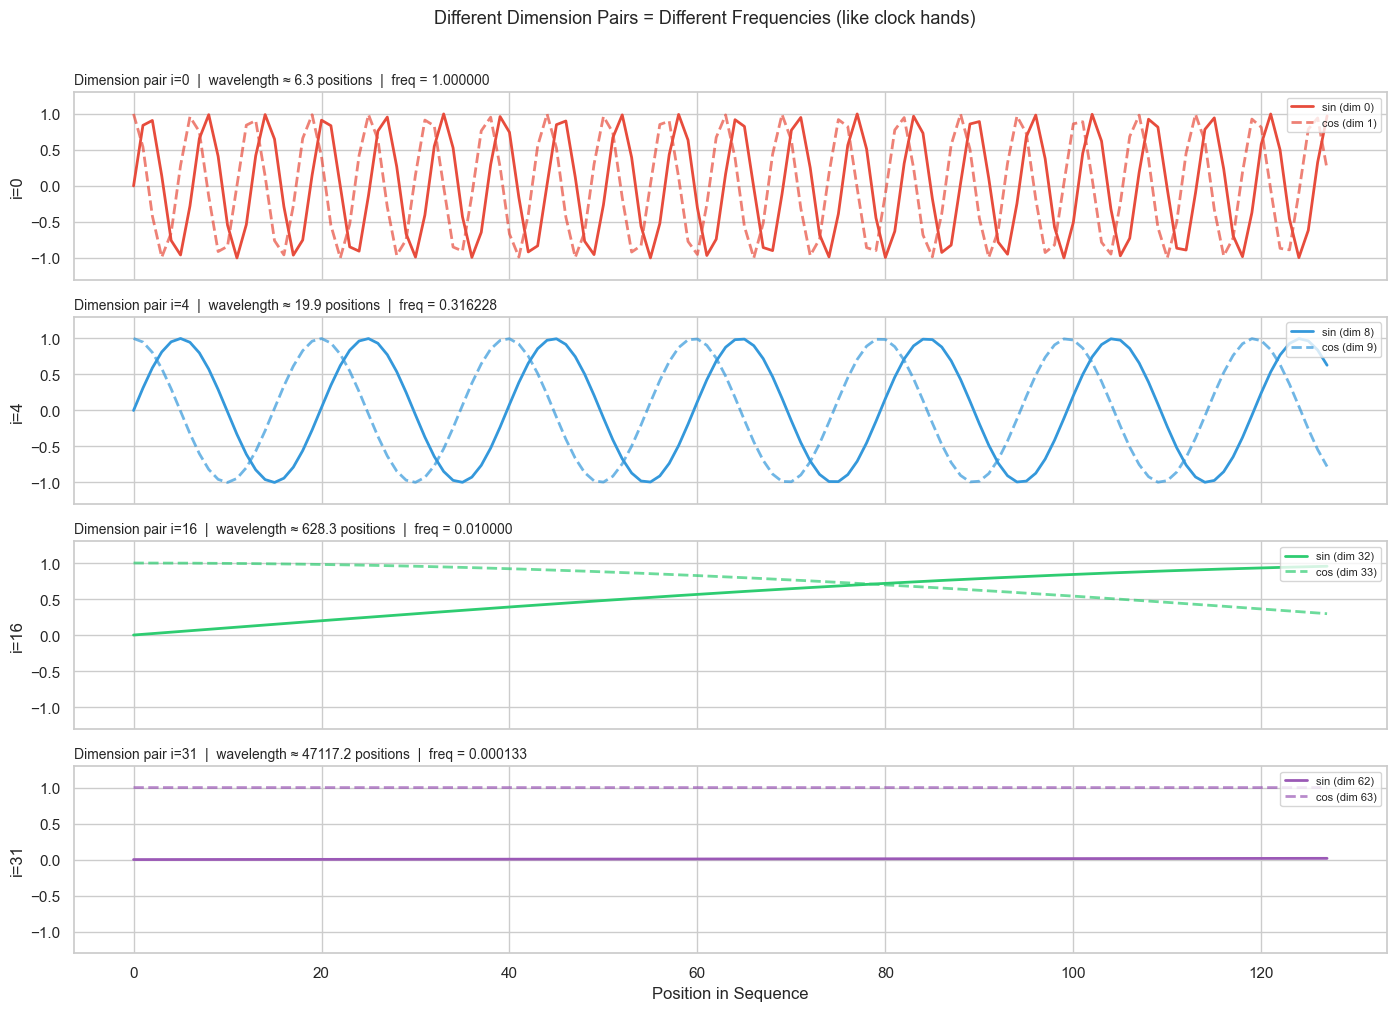

Notice:
  • i=0  → wavelength ≈ 6.3 (completes a full cycle every ~6 positions)
  • i=31 → wavelength ≈ 628318 (barely changes across 128 positions)
  • Together they create a UNIQUE pattern for each position


In [5]:
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
positions = np.arange(max_len)

dim_pairs = [0, 4, 16, 31]  # i values → dimension pairs (2i, 2i+1)
colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6']

for ax, i, color in zip(axes, dim_pairs, colors):
    freq = 1.0 / (10000 ** (2 * i / d_model))
    wavelength = 2 * np.pi / freq if freq > 0 else float('inf')
    
    ax.plot(positions, pe[:, 2*i].numpy(), label=f'sin (dim {2*i})', color=color, linewidth=2)
    ax.plot(positions, pe[:, 2*i+1].numpy(), label=f'cos (dim {2*i+1})', color=color, 
            linewidth=2, linestyle='--', alpha=0.7)
    ax.set_ylabel(f'i={i}')
    ax.set_title(f'Dimension pair i={i}  |  wavelength ≈ {wavelength:.1f} positions  |  freq = {freq:.6f}', 
                 fontsize=10, loc='left')
    ax.legend(loc='upper right', fontsize=8)
    ax.set_ylim(-1.3, 1.3)

axes[-1].set_xlabel('Position in Sequence')
fig.suptitle('Different Dimension Pairs = Different Frequencies (like clock hands)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print("Notice:")
print("  • i=0  → wavelength ≈ 6.3 (completes a full cycle every ~6 positions)")
print("  • i=31 → wavelength ≈ 628318 (barely changes across 128 positions)")
print("  • Together they create a UNIQUE pattern for each position")

### 3c. Each position has a unique fingerprint

Let's verify: are the PE vectors for different positions actually distinct?
We'll compute cosine similarity between all pairs of positions.

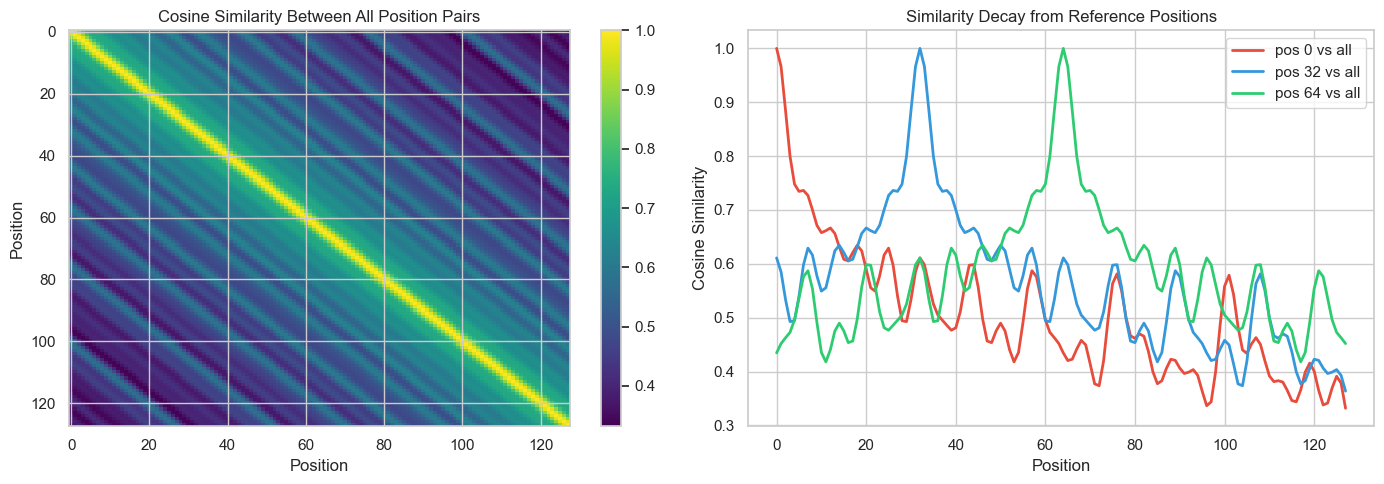

Key observations:
  • Diagonal is 1.0 (each position is identical to itself)
  • Nearby positions are more similar (smooth gradient near diagonal)
  • Distant positions are less similar → natural distance signal
  • Each position has a UNIQUE fingerprint in the embedding space


In [6]:
# Cosine similarity between all position pairs
pe_normalized = pe / pe.norm(dim=1, keepdim=True)
similarity = pe_normalized @ pe_normalized.T

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full similarity matrix
im0 = axes[0].imshow(similarity.numpy(), cmap='viridis', aspect='auto')
axes[0].set_xlabel('Position')
axes[0].set_ylabel('Position')
axes[0].set_title('Cosine Similarity Between All Position Pairs')
plt.colorbar(im0, ax=axes[0])

# Similarity of position 0 with all others
axes[1].plot(similarity[0].numpy(), color='#e74c3c', linewidth=2, label='pos 0 vs all')
axes[1].plot(similarity[32].numpy(), color='#3498db', linewidth=2, label='pos 32 vs all')
axes[1].plot(similarity[64].numpy(), color='#2ecc71', linewidth=2, label='pos 64 vs all')
axes[1].set_xlabel('Position')
axes[1].set_ylabel('Cosine Similarity')
axes[1].set_title('Similarity Decay from Reference Positions')
axes[1].legend()

plt.tight_layout()
plt.show()

print("Key observations:")
print("  • Diagonal is 1.0 (each position is identical to itself)")
print("  • Nearby positions are more similar (smooth gradient near diagonal)")
print("  • Distant positions are less similar → natural distance signal")
print("  • Each position has a UNIQUE fingerprint in the embedding space")

## Part 4: How Positional Encoding Flows into Q, K, V

This is the crucial part. In the original transformer:

```
input_to_attention = token_embedding + positional_encoding
Q = (token_emb + PE) @ W_q
K = (token_emb + PE) @ W_k  
V = (token_emb + PE) @ W_v
```

The addition means Q, K, V each contain **both** semantic and positional information.

Let's expand the attention score to see what's really happening:

$$q_m \cdot k_n = (e_m + p_m)W_q \cdot (e_n + p_n)W_k$$

Expanding this dot product:

$$= \underbrace{e_m W_q \cdot e_n W_k}_{\text{content-content}} + \underbrace{e_m W_q \cdot p_n W_k}_{\text{content-position}} + \underbrace{p_m W_q \cdot e_n W_k}_{\text{position-content}} + \underbrace{p_m W_q \cdot p_n W_k}_{\text{position-position}}$$

Four terms! The model learns to use ALL of these:
1. **Content↔Content**: "does this word relate to that word?" (pure semantics)
2. **Content↔Position**: "does this word care about what's at position n?"
3. **Position↔Content**: "does position m care about that word?"
4. **Position↔Position**: "do these two positions inherently relate?" (pure positional bias)

Let's visualize each term:

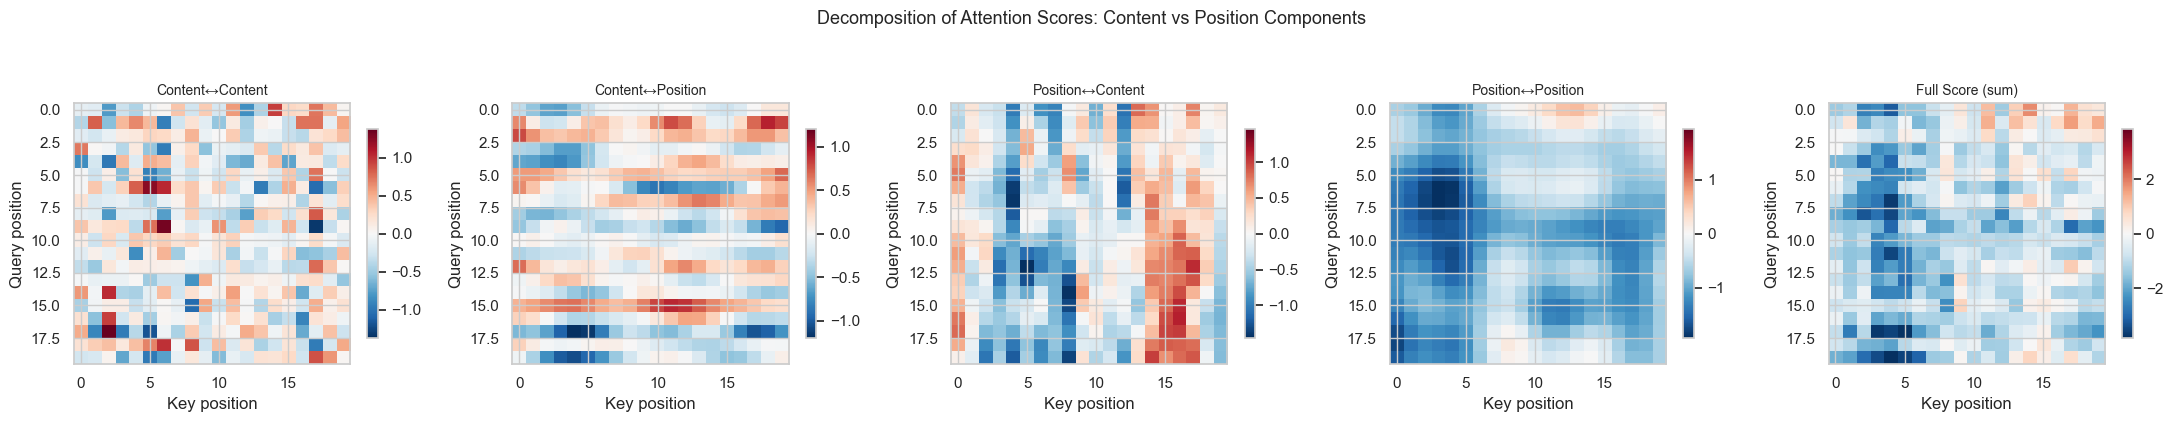

Notice the Position↔Position term:
  • It has a clear diagonal structure — nearby positions attend to each other
  • This is INDEPENDENT of content — it's a pure positional bias
  • The model uses this to learn patterns like 'the next word' or 'the previous word'


In [7]:
torch.manual_seed(42)

d_model = 32
seq_len = 20

# Simulate token embeddings (content) and positional encodings
token_emb = torch.randn(seq_len, d_model) * 0.5  # random "word meanings"
pos_enc = sinusoidal_positional_encoding(seq_len, d_model)

# Learned projection matrices
W_q = torch.randn(d_model, d_model) * 0.1
W_k = torch.randn(d_model, d_model) * 0.1

# Compute the four attention score components
# Full: (e + p) W_q @ ((e + p) W_k)^T
e_Wq = token_emb @ W_q  # content queries
p_Wq = pos_enc @ W_q    # position queries
e_Wk = token_emb @ W_k  # content keys
p_Wk = pos_enc @ W_k    # position keys

content_content = e_Wq @ e_Wk.T    # term 1
content_position = e_Wq @ p_Wk.T   # term 2
position_content = p_Wq @ e_Wk.T   # term 3
position_position = p_Wq @ p_Wk.T  # term 4

full_score = content_content + content_position + position_content + position_position

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
titles = ['Content↔Content', 'Content↔Position', 'Position↔Content', 
          'Position↔Position', 'Full Score (sum)']
matrices = [content_content, content_position, position_content, 
            position_position, full_score]

for ax, title, mat in zip(axes, titles, matrices):
    vmax = mat.abs().max().item()
    im = ax.imshow(mat.detach().numpy(), cmap='RdBu_r', aspect='auto', vmin=-vmax, vmax=vmax)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Key position')
    ax.set_ylabel('Query position')
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle('Decomposition of Attention Scores: Content vs Position Components', fontsize=13, y=1.05)
plt.tight_layout()
plt.show()

print("Notice the Position↔Position term:")
print("  • It has a clear diagonal structure — nearby positions attend to each other")
print("  • This is INDEPENDENT of content — it's a pure positional bias")
print("  • The model uses this to learn patterns like 'the next word' or 'the previous word'")

## Part 5: Attention With vs Without Positional Encoding

Let's see how adding PE changes the attention pattern on a real-ish example:

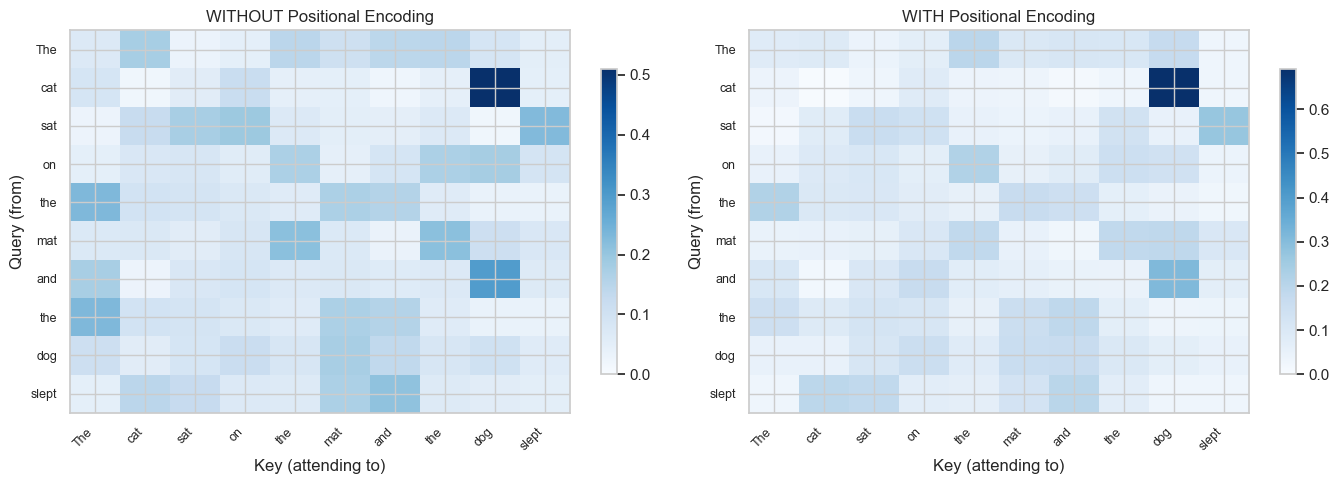

WITHOUT PE:
  • "the" at positions 0, 4, 7 all have IDENTICAL attention patterns
  • The model cannot distinguish the first "the" from the last "the"

WITH PE:
  • Each "the" now has a DIFFERENT attention pattern based on its position
  • The model can learn "the word before a noun" vs "the word starting a clause"


In [8]:
torch.manual_seed(123)

d_model = 32
sentence = ["The", "cat", "sat", "on", "the", "mat", "and", "the", "dog", "slept"]
seq_len = len(sentence)

# Simulate token embeddings (same word = same embedding)
vocab_emb = {w: torch.randn(d_model) for w in set(sentence)}
token_emb = torch.stack([vocab_emb[w] for w in sentence])  # (seq_len, d_model)

pos_enc = sinusoidal_positional_encoding(seq_len, d_model)

W_q = torch.randn(d_model, d_model) * 0.15
W_k = torch.randn(d_model, d_model) * 0.15

def compute_attention_weights(X):
    Q = X @ W_q
    K = X @ W_k
    scores = Q @ K.T / (d_model ** 0.5)
    return torch.softmax(scores, dim=-1)

attn_no_pe = compute_attention_weights(token_emb)
attn_with_pe = compute_attention_weights(token_emb + pos_enc)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, attn, title in zip(axes, [attn_no_pe, attn_with_pe], 
                             ['WITHOUT Positional Encoding', 'WITH Positional Encoding']):
    im = ax.imshow(attn.detach().numpy(), cmap='Blues', aspect='auto', vmin=0)
    ax.set_xticks(range(seq_len))
    ax.set_yticks(range(seq_len))
    ax.set_xticklabels(sentence, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(sentence, fontsize=9)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Key (attending to)')
    ax.set_ylabel('Query (from)')
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.show()

print('WITHOUT PE:')
print('  • "the" at positions 0, 4, 7 all have IDENTICAL attention patterns')
print('  • The model cannot distinguish the first "the" from the last "the"')
print()
print('WITH PE:')
print('  • Each "the" now has a DIFFERENT attention pattern based on its position')
print('  • The model can learn "the word before a noun" vs "the word starting a clause"')

## Part 6: Why Sinusoidal PE Can't Scale Beyond Training Length

The sinusoidal functions themselves extrapolate perfectly — sin and cos are defined for all positions.
So why can't the model handle longer sequences?

The problem is that **the model's learned weights (W_q, W_k) have only seen position interactions
within the training range**. The Position↔Position attention patterns for distant positions
are out-of-distribution.

Let's visualize this:

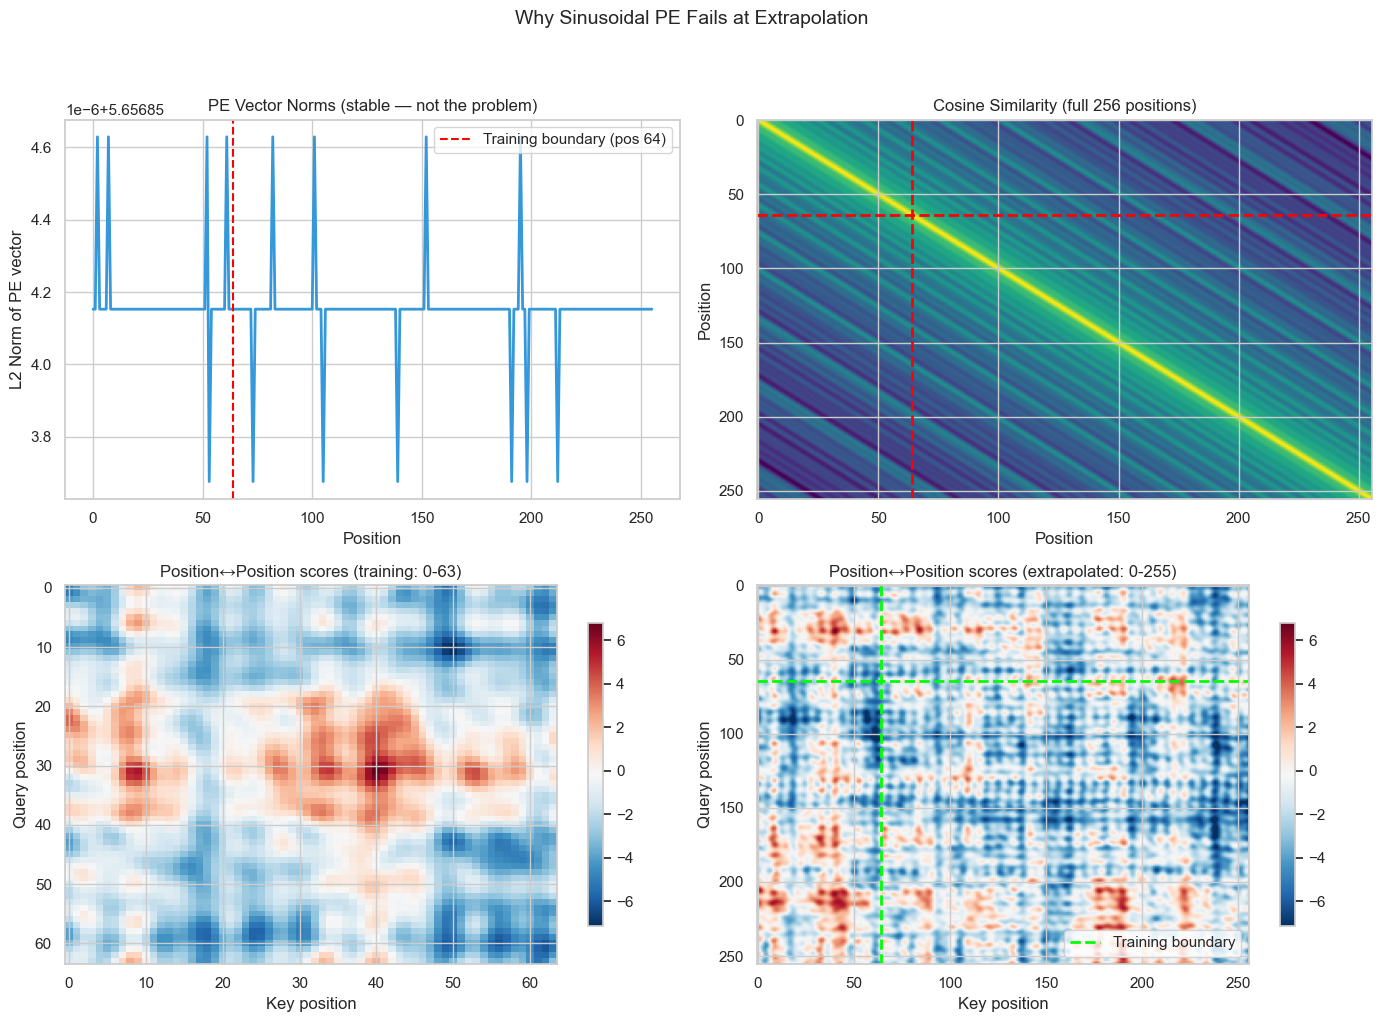

The bottom-right quadrant of the extrapolated matrix (beyond green lines)
shows position↔position interactions the model has NEVER seen during training.

The learned W_q and W_k weights have no idea how to handle these patterns.
This is why the model's output degrades — it's not the PE that breaks,
it's the LEARNED ATTENTION PATTERNS that don't generalize.


In [9]:
# Train on 64 positions, try to use 256
train_len = 64
test_len = 256
d_model = 64

pe_train = sinusoidal_positional_encoding(train_len, d_model)
pe_test = sinusoidal_positional_encoding(test_len, d_model)

# The PE vectors themselves are fine — let's check their norms
norms_test = pe_test.norm(dim=1)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: PE norms across positions
axes[0, 0].plot(norms_test.numpy(), color='#3498db', linewidth=2)
axes[0, 0].axvline(x=train_len, color='red', linestyle='--', label=f'Training boundary (pos {train_len})')
axes[0, 0].set_xlabel('Position')
axes[0, 0].set_ylabel('L2 Norm of PE vector')
axes[0, 0].set_title('PE Vector Norms (stable — not the problem)')
axes[0, 0].legend()

# Plot 2: Cosine similarity — train positions vs ALL positions
pe_test_norm = pe_test / pe_test.norm(dim=1, keepdim=True)
sim_full = pe_test_norm @ pe_test_norm.T

axes[0, 1].imshow(sim_full.numpy(), cmap='viridis', aspect='auto')
axes[0, 1].axhline(y=train_len, color='red', linestyle='--', linewidth=2)
axes[0, 1].axvline(x=train_len, color='red', linestyle='--', linewidth=2)
axes[0, 1].set_title('Cosine Similarity (full 256 positions)')
axes[0, 1].set_xlabel('Position')
axes[0, 1].set_ylabel('Position')

# Plot 3: The REAL problem — dot product patterns change
# Simulate learned W_q, W_k that were trained on 64 positions
torch.manual_seed(42)
W_q = torch.randn(d_model, d_model) * 0.1
W_k = torch.randn(d_model, d_model) * 0.1

# Position-position attention scores
pp_train = (pe_train @ W_q) @ (pe_train @ W_k).T
pp_test = (pe_test @ W_q) @ (pe_test @ W_k).T

im2 = axes[1, 0].imshow(pp_train.detach().numpy(), cmap='RdBu_r', aspect='auto')
axes[1, 0].set_title(f'Position↔Position scores (training: 0-{train_len-1})')
axes[1, 0].set_xlabel('Key position')
axes[1, 0].set_ylabel('Query position')
plt.colorbar(im2, ax=axes[1, 0], shrink=0.8)

im3 = axes[1, 1].imshow(pp_test.detach().numpy(), cmap='RdBu_r', aspect='auto',
                          vmin=pp_train.min().item(), vmax=pp_train.max().item())
axes[1, 1].axhline(y=train_len, color='lime', linestyle='--', linewidth=2, label='Training boundary')
axes[1, 1].axvline(x=train_len, color='lime', linestyle='--', linewidth=2)
axes[1, 1].set_title(f'Position↔Position scores (extrapolated: 0-{test_len-1})')
axes[1, 1].set_xlabel('Key position')
axes[1, 1].set_ylabel('Query position')
axes[1, 1].legend(loc='lower right')
plt.colorbar(im3, ax=axes[1, 1], shrink=0.8)

plt.suptitle('Why Sinusoidal PE Fails at Extrapolation', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("The bottom-right quadrant of the extrapolated matrix (beyond green lines)")
print("shows position↔position interactions the model has NEVER seen during training.")
print()
print("The learned W_q and W_k weights have no idea how to handle these patterns.")
print("This is why the model's output degrades — it's not the PE that breaks,")
print("it's the LEARNED ATTENTION PATTERNS that don't generalize.")

## Part 7: The Relative Position Property (and its limitation)

The original paper claimed that sinusoidal PE allows the model to learn relative positions
because $PE(pos+k)$ can be expressed as a **linear transformation** of $PE(pos)$.

Specifically, for any fixed offset $k$, there exists a matrix $M_k$ such that:

$$PE(pos + k) = M_k \cdot PE(pos)$$

This is because sin/cos addition formulas give us:
$$\sin(pos \cdot \omega + k \cdot \omega) = \sin(pos \cdot \omega)\cos(k \cdot \omega) + \cos(pos \cdot \omega)\sin(k \cdot \omega)$$

Let's verify this property:

PE(15) actual:    [ 0.6503 -0.7597 -0.9995  0.031   0.9975  0.0707  0.4568  0.8896]
M_5 @ PE(10):     [ 0.6503 -0.7597 -0.9995  0.031   0.9975  0.0707  0.4568  0.8896]
Max error:            2.18e-07



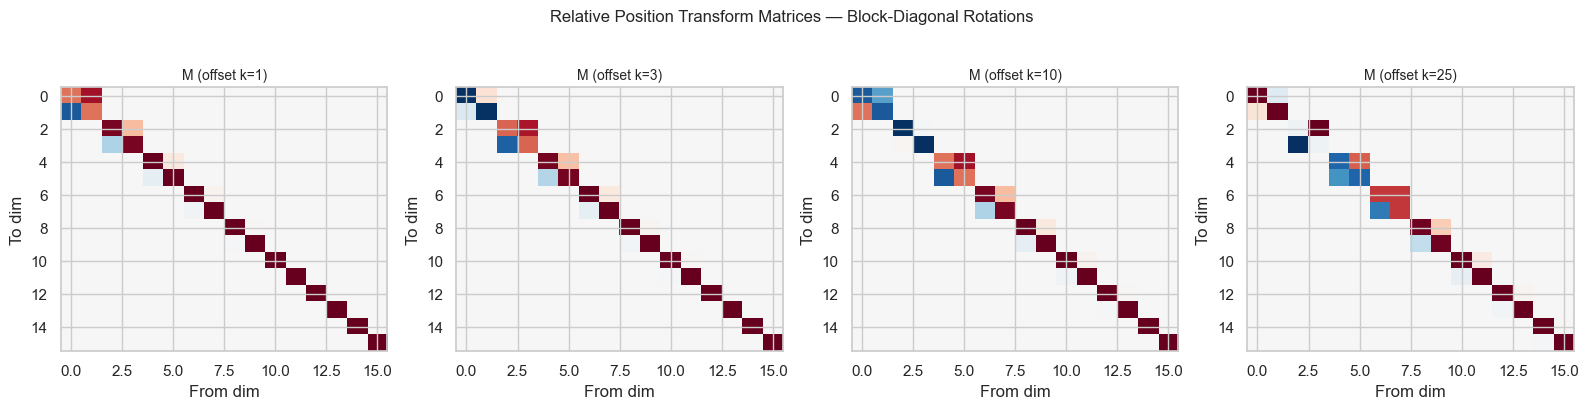

Each M_k is a block-diagonal matrix of 2×2 rotation matrices.
This means PE(pos+k) is a ROTATION of PE(pos) — the relationship is linear!

HOWEVER: the model must LEARN to exploit this linear relationship through W_q and W_k.
In practice, the model partially learns this, but not perfectly — which is why
RoPE (which DIRECTLY applies rotations to Q and K) works so much better.


In [10]:
d_model = 16  # small for clarity
max_len = 50
pe = sinusoidal_positional_encoding(max_len, d_model)

# For offset k, the linear transformation M_k is a block-diagonal matrix
# of 2x2 rotation matrices
def build_relative_transform(k, d_model):
    """Build the matrix M_k such that PE(pos+k) = M_k @ PE(pos)."""
    M = torch.zeros(d_model, d_model)
    for i in range(d_model // 2):
        omega = 1.0 / (10000 ** (2 * i / d_model))
        angle = k * omega
        # 2x2 rotation block for dimension pair (2i, 2i+1)
        M[2*i, 2*i] = np.cos(angle)      # sin(pos+k) depends on sin(pos)
        M[2*i, 2*i+1] = np.sin(angle)    # sin(pos+k) depends on cos(pos)
        M[2*i+1, 2*i] = -np.sin(angle)   # cos(pos+k) depends on sin(pos)
        M[2*i+1, 2*i+1] = np.cos(angle)  # cos(pos+k) depends on cos(pos)
    return M

# Verify: PE(pos+k) should equal M_k @ PE(pos)
k = 5
M_k = build_relative_transform(k, d_model)

pos = 10
pe_pos = pe[pos]
pe_pos_plus_k = pe[pos + k]
pe_predicted = M_k @ pe_pos

print(f"PE({pos+k}) actual:    {pe_pos_plus_k[:8].numpy().round(4)}")
print(f"M_{k} @ PE({pos}):     {pe_predicted[:8].numpy().round(4)}")
print(f"Max error:            {(pe_pos_plus_k - pe_predicted).abs().max().item():.2e}")
print()

# Visualize M_k for different offsets
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, k in zip(axes, [1, 3, 10, 25]):
    M = build_relative_transform(k, d_model)
    ax.imshow(M.numpy(), cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
    ax.set_title(f'M (offset k={k})', fontsize=10)
    ax.set_xlabel('From dim')
    ax.set_ylabel('To dim')

plt.suptitle('Relative Position Transform Matrices — Block-Diagonal Rotations', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print("Each M_k is a block-diagonal matrix of 2×2 rotation matrices.")
print("This means PE(pos+k) is a ROTATION of PE(pos) — the relationship is linear!")
print()
print("HOWEVER: the model must LEARN to exploit this linear relationship through W_q and W_k.")
print("In practice, the model partially learns this, but not perfectly — which is why")
print("RoPE (which DIRECTLY applies rotations to Q and K) works so much better.")

## Summary

| Aspect | Sinusoidal PE |
|--------|--------------|
| **Type** | Absolute (added to embeddings) |
| **Uniqueness** | ✅ Each position gets a unique fingerprint |
| **Relative position** | ⚠️ Theoretically possible via linear transform, but model must learn it |
| **Extrapolation** | ❌ Model's learned W_q, W_k don't generalize beyond training length |
| **Where applied** | Added to input embeddings → flows into Q, K, AND V |
| **Scalability** | Limited to training sequence length |

### The path forward:
- **Learned PE** (BERT, GPT-2): Even worse — hard ceiling at max_position
- **Relative PE** (Transformer-XL): Better, but complex and still limited
- **RoPE**: Applies rotation directly to Q, K — relative position falls out naturally
- **ALiBi**: Simplest — just a linear distance penalty on attention scores

Next notebook: **RoPE — how rotations in Q/K space solve the scaling problem** 🚀